# Statistiques Descriptives : Théorie, Interprétation et Application sur un Dataset E-commerce #

In [6]:
# pour des graphiques plus jolis
!pip install seaborn

In [7]:
# Imports de base
# pour calcul num 
import numpy as np

# pour manip de donées tabulaires
import pandas as pd

#création de graphiques et visualisations
import matplotlib.pyplot as plt

# pour stats avancées
from scipy import stats

import seaborn as sns
sns.set(style="whitegrid")

# affichage plus lisible
pd.set_option("display.max_columns", None)

In [8]:
# chargement du jeu de données 
df = pd.read_csv("ecommerce_dataset.csv")
df.head()

,client_id,sexe,âge,revenu_mensuel,segment_age,revenu_cat,produit,canal_achat,montant_panier,panier_frequent,note_satisfaction,retour_produit,date_achat
0,1,Homme,50,3893.70,Mature,Moyen,Sport,Mobile,83.27,Non,2,Non,2023-05-28
1,2,Femme,39,2885.15,Adulte,Moyen,Électronique,Mobile,47.18,Oui,3,Non,2023-01-13
2,3,Homme,44,2369.53,Mature,Moyen,Sport,Mobile,72.28,Oui,4,Non,2023-03-13
3,4,Homme,38,3197.92,Adulte,Moyen,Électronique,Mobile,54.59,Non,3,Non,2023-05-07
4,5,Homme,20,3774.66,Jeune,Moyen,Sport,Mobile,75.30,Non,4,Non,2023-07-04


In [9]:
# aperçu rapide de la structure du jeu 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   client_id          15000 non-null  int64  
 1   sexe               15000 non-null  object 
 2   âge                15000 non-null  int64  
 3   revenu_mensuel     15000 non-null  float64
 4   segment_age        15000 non-null  object 
 5   revenu_cat         15000 non-null  object 
 6   produit            15000 non-null  object 
 7   canal_achat        15000 non-null  object 
 8   montant_panier     15000 non-null  float64
 9   panier_frequent    15000 non-null  object 
 10  note_satisfaction  15000 non-null  int64  
 11  retour_produit     15000 non-null  object 
 12  date_achat         15000 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 1.5+ MB


Je vais principalement utiliser 

- des **variables quantitatives** : `âge`, `revenu_mensuel`, `montant_panier`, `note_satisfaction` ;
- des **variables qualitatives** : `sexe`, `segment_age`, `revenu_cat`, `produit`, `canal_achat`, `panier_frequent`, `retour_produit`.


Une **variable quantitative** est une variable numérique.  
Elle peut discrète ou continue

#  Analyse univariée des variables quantitatives  


Une variable quantitative peut être résumée selon plusieurs axes :  
**tendance centrale**, **dispersion**, **position**, **forme de la distribution**, **visualisation**


##  Important  
Une analyse univariée quantitative répond à 5 questions clés :

1. **Quel est le niveau moyen ?**  moyenne, médiane  
2. **Quelle est la variabilité ?**  variance, écart-type, étendue  
3. **Comment se répartissent les observations ?**  quartiles, quantiles, IQR  
4. **Quelle est la forme de la distribution ?** skewness, kurtosis  
6. **Comment visualiser efficacement ?** histogramme, KDE, boxplot


###  Mesures de tendance centrale

Les mesures de tendance centrale résument le **niveau "moyen"** de la variable.

- **Moyenne** 
- **Médiane** 
- **Mode** : valeur qui apparaît le plus souvent.

In [10]:
# extrait de la variable quantitative que je vais analyser
variable = "montant_panier"
serie = df[variable].dropna()

serie.describe()

count    15000.000000
mean        93.357107
std         66.260809
min         10.320000
25%         48.310000
50%         73.530000
75%        117.295000
max        929.970000
Name: montant_panier, dtype: float64

In [11]:

# Les calculs en Python

mean_value = serie.mean()
median_value = serie.median()
mode_values = serie.mode()  # peut retourner plusieurs valeurs

print(f"Moyenne : {mean_value:.2f}")
print(f"Médiane : {median_value:.2f}")
print("Mode(s) :")
print(mode_values)


Moyenne : 93.36
Médiane : 73.53
Mode(s) :
0    62.12
Name: montant_panier, dtype: float64



**Interprétation :**
- Si la moyenne et la médiane sont proches, la distribution est souvent relativement symétrique.
- Si la moyenne est nettement > médiane → asymétrie à droite.  
- Si la moyenne est nettement < médiane → asymétrie à gauche.

*La moyenne est tirée vers la queue par les valeurs extrêmes, donc son ecart avec la médiane est révelateur d'une asymetrie dans les données. Plus celui-ci est impportant plus celle-ci est forte.*

Ici, la ***moyenne*** est nettement supérieure à la médiane -> asymétrie à droite. Il y a probablement quelques clients avec des paniers très élevés (proches de 930€) qui tirent la moyenne vers le haut. La ***médiane*** de 73,53€ est donc plus représentative du client typique que la moyenne, la moitié des clients dépense moins de 73,53€ par commande.
Pour ce qui est du ***mode***, les montants de paniers sont des décimales donc la probabilité que des clients aient excatement le même montant est faible.

In [12]:
#compte combien de fois les dix premières valeurs apparaissent dans la série
serie.value_counts().head(10)

montant_panier
62.12    9
41.08    7
48.16    7
55.83    7
40.71    7
51.87    7
41.75    7
68.88    7
90.81    6
53.16    6
Name: count, dtype: int64

Le ***mode*** est statistiquement non significatif sur cette variable. Il n'y pas de montant qui revient vraiment souvent dans les données. Un mode est significatif quand il se démarque nettement des autres valeurs. Ici sur ce data set de 15 000 transactions, 9 représente que 0,06%.

###   Mesures de dispersion

Les mesures de dispersion indiquent *à quel point les valeurs sont serrées ou éparpillées*.

- **Variance** :  À quel point les valeurs s'éloignent de la moyenne en moyenne
- **Écart-type** : Même chose que la variance mais dans la même unité que les données (racine carrée de la variance) 
- **Étendue** : max - min  
- **Coefficient de variation (CV)** : permet de comparer **relativement** la dispersion à la moyenne. Correspond à l'écart-type divisé par la moyenne, et est exprimé en *%*
- **IQR (Interquartile Range)** : Mesure la dispersition au centre. L'écart entre les 25% les plus bas (Q1) et les 25% les plus hauts (Q3). *Il ignore les valeurs extrêmes, donc il est robuste aux asymétries* Plus l’IQR est grand → plus la variable est dispersée au centre car IQR = zone contenant **50% des valeurs centrales** 


In [13]:
#calcul de la variance, de l'écart-type, de l'étendue et du CV

variance = serie.var(ddof=1)          # variance empirique (correction de Bessel).
std_dev = serie.std(ddof=1)           # écart-type
vmin = serie.min()
vmax = serie.max()
etendue = vmax - vmin
cv = (std_dev / mean_value) * 100
q1 = serie.quantile(0.25)
q3 = serie.quantile(0.75)
iqr = q3 - q1                  

print(f"Variance : {variance:.2f}")
print(f"Écart-type : {std_dev:.2f}")
print(f"Min : {vmin:.2f}")
print(f"Max : {vmax:.2f}")
print(f"Étendue : {etendue:.2f}")
print(f"Coefficient de variation : {cv:.2f} %")
print(f"IQR : {iqr:.2f}")

Variance : 4390.49
Écart-type : 66.26
Min : 10.32
Max : 929.97
Étendue : 919.65
Coefficient de variation : 70.98 %
IQR : 68.98


Le résultat de la variance est en unité au carré, ici les données sont en €, la variance est donc en €². 
Ce resultat est difficile à interpréter, c'est pour ça qu'on lui préfère **l'écart-type** dans l'interprétation du quotidien qui est la racine carrée de la variance, et donc dans la **même unité que les données**.

La variable présente une forte dispersion avec un écart-type de 66,26€, soit un coefficient de variation de 71%. Cela signifie que les montants de panier sont très hétérogènes d'un client à l'autre. 

**L'IQR** de 68,99€ confirme cette dispersion même au centre de la distribution. La valeur maximale de 929,97€ suggère la présence d'outliers qui contribuent à gonfler la variance (4390,38€²) et l'écart-type.


###  Quartiles, quantiles et outliers

Pour analyser la répartition d’une variable quantitative, on utilise des **mesures de position** telles que les quartiles et quantiles, ainsi que des bornes permettant de détecter les valeurs aberrantes (outliers).

Les quartiles repondent à la question. **Où est-ce que cette valeur se situe par rapport aux autres ?**


##  **Quartiles (Q1, Q2, Q3)**  
Les quartiles découpent la distribution en **4 sous groupes égaux** :

- **Q1 (1er quartile)** : 25% des valeurs sont en dessous  
- **Q2 (médiane)** : 50% des valeurs sont en dessous  
- **Q3 (3e quartile)** : 75% des valeurs sont en dessous  

Ils permettent de comprendre **où se concentre la majorité des données**.


##  **Quantiles (déciles, percentiles)**  
Les quantiles généralisent les quartiles en découpant la distribution en **n parties égales**. 

*Médiane, quartiles, déciles, percentiles -> ce sont tous des quantiles.*

- **Déciles (D1, D2, …, D9)** → 10 segments  
- **Percentiles (P1 à P99)** → 100 segments  

Utile pour analyser des données très dispersées ou pour créer des groupes (segmentation, scoring, etc.).


##  **Détection des outliers (valeurs extrêmes)**  
Les valeurs extrêmes peuvent être identifiées à l’aide des **bornes de Tukey** :

- **Borne inférieure** :  
  \[
  Q_1 - 1.5 \times IQR
  \]

- **Borne supérieure** :  
  \[
  Q_3 + 1.5 \times IQR
  \]

Toute valeur située **en dehors de ces bornes** est considérée comme un *outlier* potentiel.

Cette approche est la même que celle utilisée dans les **boxplots**.


In [14]:
# Calcul des quartiles et des bornes pour détecter les outliers

q1 = serie.quantile(0.25)
q2 = serie.quantile(0.50)
q3 = serie.quantile(0.75)

borne_inf = q1 - 1.5 * iqr
borne_sup = q3 + 1.5 * iqr

print(f"Q1 : {q1:.2f}")
print(f"Q2 (médiane) : {q2:.2f}")
print(f"Q3 : {q3:.2f}")
print(f"Borne inférieure (outliers) : {borne_inf:.2f}")
print(f"Borne supérieure (outliers) : {borne_sup:.2f}")

outliers = serie[(serie < borne_inf) | (serie > borne_sup)]
print(f"\nNombre d'outliers détectés : {outliers.shape[0]}")

Q1 : 48.31
Q2 (médiane) : 73.53
Q3 : 117.30
Borne inférieure (outliers) : -55.17
Borne supérieure (outliers) : 220.77

Nombre d'outliers détectés : 813


#### Les quartiles
50% des clients dépensent entre 48,31€ et 117,30€. C'est la zone "normale" de dépense. Le client typique (médiane) dépense 73,53€.

#### Les bornes outliers
La borne inférieure est à -55,17€. Un montant de panier négatif est impossible, donc en pratique il n'y a pas d'outliers vers le bas. La borne supérieure est à 220,77€. Tout client dépensant plus de 220,77€ est considéré comme un outlier.

#### 813 outliers
813 clients sur 15 000 soit environ 5,4% du dataset. Ce sont tous des outliers vers le haut avec des gros paniers dépassant 220,77€.

### Forme de la distribution : asymétrie et aplatissement

Deux indicateurs classiques :

- **Asymétrie (skewness)** : mesure la symétrie de la distribution. (ou est tirée la oyenne par rapport à la médiane)  
  - skewness ≈ 0 → distribution à peu près symétrique ;  
  - skewness > 0 → queue à droite ;  
  - skewness < 0 → queue à gauche.

       *Entre -0.5 et 0.5 → asymétrie faible, quasi symétrique*
       *Entre 0.5 et 1 (ou -1 et -0.5) → asymétrie modérée*
       *Au delà de 1 (ou en dessous de -1) → asymétrie forte* 

- **Aplatissement (kurtosis)** : mesure la forme des queues de distribution.  
  - kurtosis ≈ 0 (en version « excess kurtosis ») → proche de la loi normale ;  
  - kurtosis > 0 → distribution plus « pointue », queues plus lourdes ;  
  - kurtosis < 0 → distribution plus « plate ».

*D'après ce que je sais déjà (asymétrie à droite, outliers vers le haut), je devrais obtenir un skewness positif et élevé et un kurtosis positif*

In [15]:
# calcul de l'asymétrie et de l'aplatissement

skewness = serie.skew()
kurtosis = serie.kurt()  # kurtosis "excess" (0 si normale théorique)
 
print(f"Skewness (asymétrie) : {skewness:.3f}")
print(f"Kurtosis (aplatissement) : {kurtosis:.3f}")

Skewness (asymétrie) : 2.150
Kurtosis (aplatissement) : 7.737


### Visualisations (histogramme, KDE, boxplot)

Les graphiques permettent de **voir** la distribution :

- **Histogramme** : fréquence des valeurs dans des classes ;
- **KDE (Kernel Density Estimation)** : estimation lissée de la densité ;
- **Boxplot** : résumé visuel (médiane, quartiles, outliers).

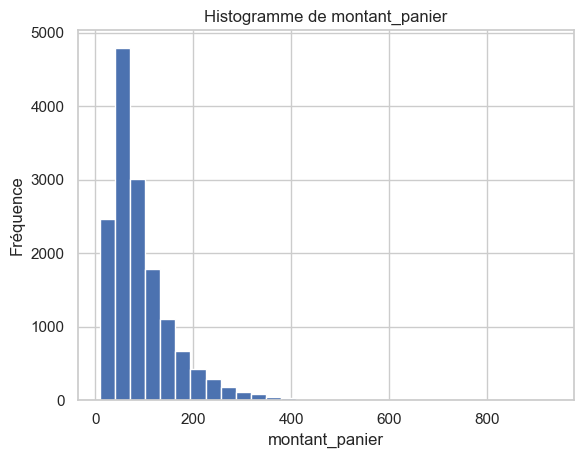

In [16]:

#  Histogramme

plt.figure()
plt.hist(serie, bins=30)
plt.title(f"Histogramme de {variable}")
plt.xlabel(variable)
plt.ylabel("Fréquence")
plt.show()


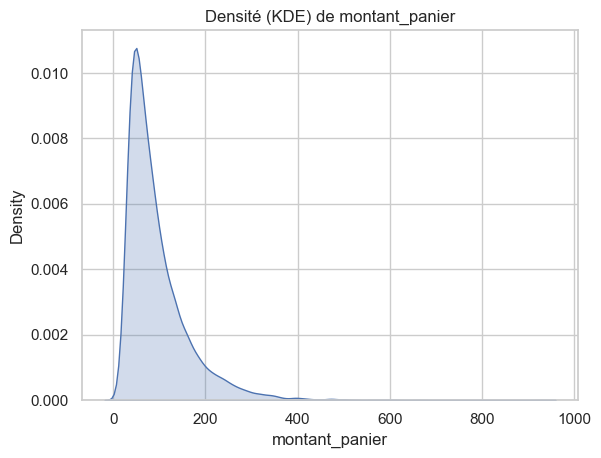

In [17]:
#  Densité (KDE) 

plt.figure()
sns.kdeplot(serie, fill=True)
plt.title(f"Densité (KDE) de {variable}")
plt.xlabel(variable)
plt.show()

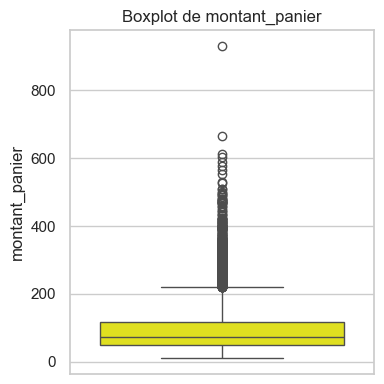

In [19]:
#  Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(4, 4))
sns.boxplot(y=serie, color="#FFFF00")

plt.title(f"Boxplot de {variable}")
plt.ylabel(variable)
plt.tight_layout()
plt.show()